# Entrenamiento PENGWIN — responsabilidad de Hoyos

Este notebook ejecuta la prueba de *overfit* intencional de semana 9 sobre un batch fijo. Reutiliza los datos/targets de Daniela, el backbone de Miguel, el CBAM de Annie y la cabeza/pérdida grid de Fabián; no redefine esos componentes.

El entrenamiento se ejecuta **solo en GPU CUDA**, con precisión mixta y el mismo batch en todas las épocas, sin aumentación. Guarda checkpoint e historial (CSV); las curvas y la comparación visual entre *ground truth* y predicción **solo se muestran en el notebook, no se guardan como imágenes**.

> Requisitos: seleccionar un entorno con PyTorch compilado para CUDA, instalar `requirements.txt` y tener los `.mha` locales en `data_mha/`. El notebook no descarga datos ni continúa silenciosamente sin GPU o sin los cortes.

## 1. Configuración reproducible y GPU

Esta celda importa las bibliotecas, fija las semillas y configura resolución de 256 × 256, grid 16 × 16, batch de 6 y 200 épocas. **Resultado esperado:** PyTorch detecta CUDA y muestra el nombre de la GPU. Si no hay soporte CUDA, la ejecución se detiene explícitamente; no hay sustitución por CPU.

In [13]:
from PIL import Image
import ast
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = Path.cwd()
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    raise RuntimeError(
        "Este entrenamiento debe ejecutarse en GPU CUDA. "
        "Instala/selecciona un PyTorch con soporte CUDA y vuelve a ejecutar esta celda."
    )

import SimpleITK as sitk
IMAGE_SIZE = 256
GRID_SIZE = 16
BATCH_SIZE = 6                  # La guía permite 4-8; el trabajo de Fabián usa 6.
EPOCHS = 200                    # Prueba inicial de memorización, no entrenamiento final.
LEARNING_RATE = 1e-3
LOG_EVERY = 10
USE_AMP = True
OUTPUT_DIR = ROOT / "evidencias" / "entrenamiento_semana9"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.set_num_threads(max(1, min(4, torch.get_num_threads())))

print(f"PyTorch: {torch.__version__}")
print(f"GPU seleccionada: {torch.cuda.get_device_name(0)}")
print(f"Semilla: {SEED} | resolucion: {IMAGE_SIZE} | grid: {GRID_SIZE}x{GRID_SIZE}")
print(f"Batch fijo: {BATCH_SIZE} | epocas: {EPOCHS} | learning rate: {LEARNING_RATE}")
print(f"Precision mixta CUDA: {USE_AMP}")
print(f"Evidencias: {OUTPUT_DIR}")

PyTorch: 2.10.0+cu128
GPU seleccionada: NVIDIA GeForce RTX 5060
Semilla: 42 | resolucion: 256 | grid: 16x16
Batch fijo: 6 | epocas: 200 | learning rate: 0.001
Precision mixta CUDA: True
Evidencias: d:\proyecto_analitica_corte2\evidencias\entrenamiento_semana9


## 2. Cargar las implementaciones existentes del equipo

El cargador extrae únicamente definiciones ya escritas en los notebooks de datos/backbone y de CBAM/cabeza. No ejecuta sus celdas exploratorias ni modifica esos archivos. **Resultado esperado:** encontrar todas las funciones, clases y constantes requeridas; si alguna falta o cambia de nombre, detiene el flujo con un error.

In [14]:
# Se extraen únicamente las clases, funciones y constantes ya presentes en los
# notebooks del equipo. No se ejecutan las celdas de prueba de esos notebooks.

def _target_names(node):
    targets = node.targets if isinstance(node, ast.Assign) else [node.target] if isinstance(node, ast.AnnAssign) else []
    names = set()
    for target in targets:
        if isinstance(target, ast.Name):
            names.add(target.id)
        elif isinstance(target, (ast.Tuple, ast.List)):
            names.update(item.id for item in target.elts if isinstance(item, ast.Name))
    return names


def _load_existing_definitions(notebook_path, definition_names, value_names=()):
    notebook_path = Path(notebook_path)
    if not notebook_path.exists():
        raise FileNotFoundError(f"No encuentro la integración del equipo: {notebook_path}")
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    wanted_defs = set(definition_names)
    wanted_values = set(value_names)
    snippets = []
    found_defs, found_values = set(), set()

    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        try:
            tree = ast.parse(source)
        except SyntaxError:
            continue
        for node in tree.body:
            name = getattr(node, "name", None)
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and name in wanted_defs and name not in found_defs:
                snippets.append(ast.get_source_segment(source, node))
                found_defs.add(name)
            elif isinstance(node, (ast.Assign, ast.AnnAssign)):
                selected = _target_names(node) & wanted_values
                if selected and not selected.issubset(found_values):
                    snippets.append(ast.get_source_segment(source, node))
                    found_values.update(selected)

    missing_defs = wanted_defs - found_defs
    missing_values = wanted_values - found_values
    if missing_defs or missing_values:
        raise RuntimeError(
            f"Faltan integraciones del equipo en {notebook_path.name}: "
            f"funciones/clases={sorted(missing_defs)}, constantes={sorted(missing_values)}"
        )
    exec("\n\n".join(snippets), globals())
    return len(snippets)


project_defs = _load_existing_definitions(
    ROOT / "proyecto_pengwin.ipynb",
    definition_names={
        "resolve_repo_path", "apply_hu_window", "instance_to_semantic",
        "boxes_from_semantic", "letterbox_pair", "build_detection_target",
        "PengwinDetectionDataset", "FundidoraPC", "FundidoraPCPlus", "build_backbone",
    },
    value_names={"CLASS_ID_TO_NAME", "TARGET_COLORS"},
)
model_defs = _load_existing_definitions(
    ROOT / "cbam.ipynb",
    definition_names={
        "ChannelAttention", "SpatialAttention", "CBAM", "box_iou", "pairwise_iou",
        "encode_boxes", "decode_boxes", "build_targets", "GridDetectionHead",
        "split_head_output", "GridDetector", "build_detector", "grid_detection_loss",
        "decode_predictions",
    },
    value_names={
        "GRID_S", "IMG_SIZE", "STRIDE", "CH_OBJ", "CH_BOX", "CH_CLS",
        "LAMBDAS", "CLASS_NAMES",
    },
)

# Las definiciones de Miguel/Fabián usan estos nombres globales.
BASE_DIR = ROOT
SEED = 42

print(f"Datos/targets de Daniela y backbone de Miguel cargados: {project_defs} definiciones")
print(f"CBAM de Annie y cabeza/pérdidas de Fabián cargados: {model_defs} definiciones")
print("Las celdas de prueba de los notebooks fuente no se ejecutaron aquí.")

Datos/targets de Daniela y backbone de Miguel cargados: 12 definiciones
CBAM de Annie y cabeza/pérdidas de Fabián cargados: 20 definiciones
Las celdas de prueba de los notebooks fuente no se ejecutaron aquí.


## 3. Comprobar datos y crear el dataset de entrenamiento

Lee el split fijo y el manifiesto de cortes positivos, instancia el dataset 2D de Daniela y comprueba que existan los `.mha` referenciados. **Resultado esperado:** número de cortes disponibles y confirmación de rutas locales. Si faltan archivos, los enumera y no inventa ni descarga ejemplos.

In [15]:
dataset_csv = ROOT / "splits" / "dataset.csv"
manifest_csv = ROOT / "evidencias" / "datos_targets" / "manifest_cortes_positivos.csv"
DATA_READY = False
train_detection_dataset = None

if not dataset_csv.exists() or not manifest_csv.exists():
    print("No puedo preparar el dataset: falta splits/dataset.csv o el manifiesto de targets.")
else:
    df = pd.read_csv(dataset_csv, dtype={"case_id": str})
    slice_manifest = pd.read_csv(manifest_csv, dtype={"case_id": str})
    train_detection_dataset = PengwinDetectionDataset(
        split="train", image_size=IMAGE_SIZE, channels=1, as_torch=True
    )
    missing_paths = []
    for column in ("image_path", "label_path"):
        missing_paths.extend(
            str(resolve_repo_path(path))
            for path in df[column].dropna().unique()
            if not resolve_repo_path(path).exists()
        )
    DATA_READY = len(train_detection_dataset) > 0 and not missing_paths
    print(f"Casos en dataset.csv: {len(df)}")
    print(f"Cortes positivos de entrenamiento disponibles en el manifiesto: {len(train_detection_dataset)}")
    if missing_paths:
        print(f"Archivos de imagen/label ausentes: {len(missing_paths)}")
        for path in missing_paths[:4]:
            print("  -", path)
        print("Copia los MHA en data_mha/ según las rutas de splits/dataset.csv y vuelve a ejecutar.")
    elif DATA_READY:
        print("Datos locales encontrados. Se puede construir el batch de overfit.")
    else:
        print("El split de entrenamiento no contiene cortes positivos; revisa el manifiesto.")

Casos en dataset.csv: 100
Cortes positivos de entrenamiento disponibles en el manifiesto: 18072
Datos locales encontrados. Se puede construir el batch de overfit.


## 4. Verificar el contrato backbone → CBAM → grid

Construye el detector existente y ejecuta un *forward* con un tensor sintético sobre CUDA. **Resultado esperado:** salida finita `[1, 8, 16, 16]` y conteo de parámetros. Esto verifica la integración y las formas, no el aprendizaje.

In [16]:
# Un forward sintetico confirma el contrato de las piezas existentes en CUDA.
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = build_detector(backbone_name="base", use_cbam=True).to(DEVICE)
model.eval()
with torch.no_grad():
    sample_output = model(torch.zeros(1, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE))
expected_shape = (1, 8, GRID_SIZE, GRID_SIZE)
print("Modelo: FundidoraPC base + CBAM + GridDetectionHead")
print("Dispositivo de parámetros:", next(model.parameters()).device)
print("Forma de salida:", tuple(sample_output.shape), "| esperada:", expected_shape)
print("Parámetros entrenables:", sum(p.numel() for p in model.parameters() if p.requires_grad))
if next(model.parameters()).device != DEVICE:
    bad_params = [(name, p.device) for name, p in model.named_parameters() if p.device != DEVICE]
    if bad_params:
        raise RuntimeError(
            "Los parametros del detector no quedaron en la GPU seleccionada. "
            f"Parámetros fuera de {DEVICE}: {bad_params[:5]}"
        )
if not torch.isfinite(sample_output).all():
    raise RuntimeError("El forward del detector produjo valores no finitos.")
if tuple(sample_output.shape) != expected_shape:
    raise RuntimeError("La salida del detector no coincide con el contrato de Fabián.")

Modelo: FundidoraPC base + CBAM + GridDetectionHead
Dispositivo de parámetros: cuda:0
Forma de salida: (1, 8, 16, 16) | esperada: (1, 8, 16, 16)
Parámetros entrenables: 693290


## 5. Seleccionar y revisar un batch fijo

Selecciona determinísticamente seis cortes positivos de entrenamiento, carga sus imágenes y targets una sola vez y coloca las imágenes en CUDA. **Resultado esperado:** tensor `[6, 1, 256, 256]`, índices repetibles, casos/cortes, cajas y clases. El batch no cambia entre épocas y no se aplica aumentación.

In [17]:
FIXED_INDICES = []
batch_images = None
batch_targets = None
if DATA_READY:
    if len(train_detection_dataset) < BATCH_SIZE:
        print(f"No hay suficientes cortes positivos: {len(train_detection_dataset)} < {BATCH_SIZE}.")
    else:
        # Selección determinista distribuida en el split train.
        FIXED_INDICES = np.linspace(
            0, len(train_detection_dataset) - 1, BATCH_SIZE, dtype=int
        ).tolist()
        samples = [train_detection_dataset[index] for index in FIXED_INDICES]
        images, batch_targets = zip(*samples)
        batch_images = torch.stack(images).to(device=DEVICE, dtype=torch.float32)
        batch_targets = list(batch_targets)
        print("Índices fijos:", FIXED_INDICES)
        print("Batch de imágenes:", tuple(batch_images.shape), "| dispositivo:", batch_images.device)
        for pos, (index, target) in enumerate(zip(FIXED_INDICES, batch_targets), start=1):
            print(
                f"  {pos}. índice={index} | caso={target['case_id']} | corte={target['slice_index']} | "
                f"cajas={len(target['boxes'])} | clases={target['class_names']}"
            )
        if not torch.isfinite(batch_images).all():
            raise ValueError("El batch contiene valores NaN o infinitos.")
else:
    print("Batch no creado: primero deben estar disponibles los MHA locales.")

<string>:52: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
<string>:57: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)


Índices fijos: [0, 3614, 7228, 10842, 14456, 18071]
Batch de imágenes: (6, 1, 256, 256) | dispositivo: cuda:0
  1. índice=0 | caso=001 | corte=71 | cajas=1 | clases=['coxal_izquierdo']
  2. índice=3614 | caso=021 | corte=112 | cajas=3 | clases=['sacro', 'coxal_izquierdo', 'coxal_derecho']
  3. índice=7228 | caso=046 | corte=47 | cajas=2 | clases=['coxal_izquierdo', 'coxal_derecho']
  4. índice=10842 | caso=063 | corte=105 | cajas=3 | clases=['sacro', 'coxal_izquierdo', 'coxal_derecho']
  5. índice=14456 | caso=083 | corte=239 | cajas=2 | clases=['coxal_izquierdo', 'coxal_derecho']
  6. índice=18071 | caso=100 | corte=287 | cajas=1 | clases=['coxal_izquierdo']


## 6. Preparar targets del grid y pérdidas

Pasa las cajas XYXY en píxeles de Daniela al codificador de grid de Fabián para preparar objectness, coordenadas y clase. **Resultado esperado:** cantidad de cajas, celdas positivas, colisiones y pesos de pérdida existentes. Si no queda ninguna celda positiva, el batch no sirve para el overfit y no se entrena.

In [18]:
grid_targets = None
if batch_targets is not None:
    grid_targets = build_targets(batch_targets, grid_s=GRID_S, img_size=IMAGE_SIZE)
    total_boxes = sum(len(target["boxes"]) for target in batch_targets)
    positive_cells = int(grid_targets["obj_t"].sum().item())
    collisions = int(grid_targets["n_collisions"])
    print(f"Cajas GT: {total_boxes} | celdas positivas: {positive_cells} | colisiones del grid: {collisions}")
    print("Lambdas acordados en la pérdida de Fabián:", LAMBDAS)
    if positive_cells == 0:
        print("No hay celdas positivas; no se inicia el overfit con este batch.")
        grid_targets = None
else:
    print("Targets grid no preparados porque no hay batch disponible.")

Cajas GT: 12 | celdas positivas: 12 | colisiones del grid: 0
Lambdas acordados en la pérdida de Fabián: {'obj': 1.0, 'box': 1.0, 'cls': 1.0, 'noobj': 1.0, 'l1': 1.0, 'iou': 1.0}


## 6b. Métricas de evaluación y conjunto de validación fijo

Define IoU, recall y AP@0.5 (sin NMS) y separa un conjunto de validación fijo que **nunca** entra al entrenamiento. Se usa para medir dos cosas distintas: (1) si el batch se **memoriza** (métricas sobre el batch de entrenamiento en modo `eval`) y (2) cuánto **no generaliza** (la misma métrica sobre validación). **Resultado esperado:** número de cortes y casos de validación; si el nombre del split no coincide con `dataset.csv`, la validación se omite con un aviso.

In [19]:
# ---- Métricas de evaluación (modo eval, fp32, sin aumentación) ----
# Se calculan SIEMPRE con model.eval(): así se ve lo que el modelo predice de verdad,
# no lo que ve el entrenamiento con BatchNorm en modo train.
N_VAL = 24          # cortes de validación fijos (se reparten a lo largo del split)
EVAL_SCORE_MIN = 0.01   # score mínimo de candidatas que entran al cálculo de AP


def _to_np(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


def _iou_np(box, boxes):
    """IoU de una caja XYXY contra N cajas XYXY (píxeles)."""
    boxes = np.asarray(boxes, dtype=np.float64).reshape(-1, 4)
    x1 = np.maximum(box[0], boxes[:, 0]); y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2]); y2 = np.minimum(box[3], boxes[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area_a = max(box[2] - box[0], 0) * max(box[3] - box[1], 0)
    area_b = np.clip(boxes[:, 2] - boxes[:, 0], 0, None) * np.clip(boxes[:, 3] - boxes[:, 1], 0, None)
    return inter / np.maximum(area_a + area_b - inter, 1e-9)


def _average_precision(decoded, targets, class_id, iou_thr=0.5):
    """AP@iou_thr de una clase sobre un conjunto de imágenes (sin NMS: duplicados cuentan como FP)."""
    detections, gts, n_gt = [], {}, 0
    for i, (pred, tgt) in enumerate(zip(decoded, targets)):
        g_boxes = _to_np(tgt["boxes"]).reshape(-1, 4)
        g_labels = _to_np(tgt["labels"]).astype(int).reshape(-1)
        g_boxes = g_boxes[g_labels == class_id]
        gts[i] = (g_boxes, np.zeros(len(g_boxes), dtype=bool))
        n_gt += len(g_boxes)
        p_boxes = _to_np(pred["boxes"]).reshape(-1, 4)
        p_scores = _to_np(pred["scores"]).reshape(-1)
        p_labels = _to_np(pred["labels"]).astype(int).reshape(-1)
        keep = (p_labels == class_id) & (p_scores >= EVAL_SCORE_MIN)
        detections.extend((float(s), i, b) for s, b in zip(p_scores[keep], p_boxes[keep]))
    if n_gt == 0:
        return None
    detections.sort(key=lambda d: -d[0])
    tp = np.zeros(len(detections)); fp = np.zeros(len(detections))
    for k, (_, i, box) in enumerate(detections):
        g_boxes, used = gts[i]
        if len(g_boxes) == 0:
            fp[k] = 1
            continue
        ious = _iou_np(box, g_boxes)
        j = int(ious.argmax())
        if ious[j] >= iou_thr and not used[j]:
            used[j] = True; tp[k] = 1
        else:
            fp[k] = 1
    tp, fp = np.cumsum(tp), np.cumsum(fp)
    recall = tp / n_gt
    precision = tp / np.maximum(tp + fp, 1e-9)
    mrec = np.concatenate([[0.0], recall, [1.0]])
    mpre = np.concatenate([[0.0], precision, [0.0]])
    for k in range(len(mpre) - 2, -1, -1):
        mpre[k] = max(mpre[k], mpre[k + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def detection_metrics(decoded, targets, n_classes):
    """Métricas de detección a partir de las candidatas decodificadas (antes de NMS).

    mean_iou: por cada caja GT, IoU de la candidata con mayor score de su misma clase (0 si no hay).
    recall50/recall75: fracción de cajas GT con ese IoU >= 0.5 / 0.75.
    map50: promedio de AP@0.5 sobre las clases presentes en el conjunto.
    """
    ious = []
    for pred, tgt in zip(decoded, targets):
        p_boxes = _to_np(pred["boxes"]).reshape(-1, 4)
        p_scores = _to_np(pred["scores"]).reshape(-1)
        p_labels = _to_np(pred["labels"]).astype(int).reshape(-1)
        g_boxes = _to_np(tgt["boxes"]).reshape(-1, 4)
        g_labels = _to_np(tgt["labels"]).astype(int).reshape(-1)
        for g_box, g_label in zip(g_boxes, g_labels):
            same = np.flatnonzero(p_labels == g_label)
            if len(same) == 0:
                ious.append(0.0)
                continue
            best = same[p_scores[same].argmax()]
            ious.append(float(_iou_np(g_box, p_boxes[best:best + 1])[0]))
    ious = np.asarray(ious) if ious else np.zeros(1)
    aps = [a for a in (_average_precision(decoded, targets, c) for c in range(n_classes)) if a is not None]
    return {
        "mean_iou": float(ious.mean()),
        "recall50": float((ious >= 0.5).mean()),
        "recall75": float((ious >= 0.75).mean()),
        "map50": float(np.mean(aps)) if aps else float("nan"),
    }


@torch.no_grad()
def evaluate_set(model, images, targets, grid_t):
    """Pérdidas (fp32) y métricas de detección del modelo en modo eval sobre un conjunto fijo."""
    was_training = model.training
    model.eval()
    logits = model(images).float()
    losses = grid_detection_loss(logits, grid_t, lambdas=LAMBDAS)
    decoded = decode_predictions(logits, score_thresh=0.0, img_size=IMAGE_SIZE)
    if was_training:
        model.train()
    out = {f"loss_{k}": float(losses[k].detach().item()) for k in ("total", "obj", "box", "cls")}
    out.update(detection_metrics(decoded, targets, n_classes=len(CLASS_NAMES)))
    return out


# ---- Conjunto de validación fijo (nunca entra al entrenamiento) ----
val_images = val_targets = val_grid_targets = None
if DATA_READY:
    try:
        if "split" in df.columns:
            print("Splits disponibles en dataset.csv:", sorted(df["split"].astype(str).unique()))
        val_detection_dataset = PengwinDetectionDataset(
            split="val", image_size=IMAGE_SIZE, channels=1, as_torch=True
        )
        if len(val_detection_dataset) > 0:
            n_val = min(N_VAL, len(val_detection_dataset))
            VAL_INDICES = np.linspace(0, len(val_detection_dataset) - 1, n_val, dtype=int).tolist()
            val_samples = [val_detection_dataset[i] for i in VAL_INDICES]
            _val_imgs, _val_tgts = zip(*val_samples)
            val_images = torch.stack(_val_imgs).to(device=DEVICE, dtype=torch.float32)
            val_targets = list(_val_tgts)
            val_grid_targets = build_targets(val_targets, grid_s=GRID_S, img_size=IMAGE_SIZE)
            print(f"Validación fija: {len(val_targets)} cortes de {len(val_detection_dataset)} disponibles "
                  f"| casos: {sorted({t['case_id'] for t in val_targets})}")
            train_cases = {t["case_id"] for t in batch_targets}
            if train_cases & {t["case_id"] for t in val_targets}:
                print("AVISO: hay casos de validación que también están en el batch de entrenamiento.")
        else:
            print("El split 'val' no tiene cortes positivos; se omite la validación.")
    except Exception as exc:  # el nombre del split o el dataset pueden variar
        val_images = val_targets = val_grid_targets = None
        print(f"Validación omitida ({type(exc).__name__}: {exc}). Revisa el nombre del split en dataset.csv.")
else:
    print("Validación omitida: los datos locales no están disponibles.")


Splits disponibles en dataset.csv: ['test', 'train', 'val']


<string>:52: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
<string>:57: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)


Validación fija: 24 cortes de 1265 disponibles | casos: ['035', '037', '067', '071', '079']


## 7. Entrenar por *overfit* intencional en GPU

Entrena el `FundidoraPC base + CBAM + GridDetectionHead` existente con AdamW y precisión mixta CUDA sobre el batch fijo. Registra las pérdidas, el IoU y el gradiente del backbone, y guarda el mejor checkpoint. **Resultado esperado:** pérdidas finitas que tienden a bajar, IoU que mejora y gradiente no nulo. Esto demuestra aprendizaje de esas muestras, no generalización.

In [20]:
history = []
eval_history = []                # métricas en modo eval: train fijo vs validación
initial_decoded = None           # predicciones del modelo SIN entrenar (para el "antes")
TRAINING_DONE = False
training_error = None
amp_overflow_events = 0          # se inicializa aquí para que exista siempre

if grid_targets is None:
    print("Entrenamiento omitido: faltan datos locales o targets positivos.")
else:
    # Misma inicialización cada vez que se ejecuta la celda (reproducibilidad).
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    model = build_detector(backbone_name="base", use_cbam=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    best_loss = float("inf")
    best_epoch = None
    checkpoint_path = OUTPUT_DIR / "checkpoint_overfit.pth"
    start_time = time.perf_counter()
    print(f"Inicio del overfit: {EPOCHS} epocas, batch fijo de {BATCH_SIZE}, "
          f"GPU {torch.cuda.get_device_name(0)}, AMP={USE_AMP}.")

    def log_eval(epoch):
        """Evalúa en modo eval el batch fijo y la validación; guarda una fila en eval_history."""
        row_e = {"epoch": epoch}
        row_e.update({f"train_{k}": v for k, v in evaluate_set(model, batch_images, batch_targets, grid_targets).items()})
        if val_images is not None:
            row_e.update({f"val_{k}": v for k, v in evaluate_set(model, val_images, val_targets, val_grid_targets).items()})
        eval_history.append(row_e)

    # Estado inicial (época 0): predicciones y métricas ANTES de entrenar.
    model.eval()
    with torch.no_grad():
        initial_decoded = decode_predictions(model(batch_images).float(), score_thresh=0.0, img_size=IMAGE_SIZE)
    log_eval(0)
    model.train()

    consecutive_amp_skips = 0
    # Se usa while para que cada overflow de AMP (paso omitido) NO consuma una época:
    # el entrenamiento termina cuando hay EPOCHS actualizaciones reales.
    while len(history) < EPOCHS:
        epoch = len(history) + 1
        model.train()
        optimizer.zero_grad(set_to_none=True)

        # Solo el modelo corre en fp16; la pérdida se calcula en fp32 para evitar overflows.
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits = model(batch_images)
        losses = grid_detection_loss(logits.float(), grid_targets, lambdas=LAMBDAS)
        total_loss = losses["total"]

        if not torch.isfinite(total_loss):
            training_error = f"Pérdida no finita en época {epoch}; revisar targets y pérdidas."
            break

        scaler.scale(total_loss).backward()
        # Los gradientes AMP están escalados; desescalar (UNA sola vez) antes de revisarlos.
        scaler.unscale_(optimizer)

        non_finite_grads = [
            name for name, param in model.named_parameters()
            if param.grad is not None and not torch.isfinite(param.grad).all()
        ]
        if non_finite_grads:
            # GradScaler registró el overflow en unscale_: step se omite y
            # update reduce la escala para el siguiente intento.
            scale_before = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            scale_after = scaler.get_scale()
            amp_overflow_events += 1
            consecutive_amp_skips += 1
            print(
                f"AMP omitió la actualización en época {epoch}: gradientes no finitos "
                f"tras desescalar ({non_finite_grads[:3]}). Escala {scale_before:g} -> "
                f"{scale_after:g}; intento consecutivo {consecutive_amp_skips}/10."
            )
            if consecutive_amp_skips >= 10:
                training_error = (
                    f"Gradientes no finitos persistentes tras 10 reducciones de escala: "
                    f"{non_finite_grads[:5]}"
                )
                break
            continue

        consecutive_amp_skips = 0
        grad_norm = 0.0
        for param in model.parameters():
            if param.grad is not None:
                grad_norm += float(param.grad.detach().norm().item() ** 2)
        grad_norm = float(grad_norm ** 0.5)
        scaler.step(optimizer)
        scaler.update()

        row = {
            "epoch": epoch,
            "total": float(losses["total"].detach().item()),
            "obj": float(losses["obj"].detach().item()),
            "obj_pos": float(losses["obj_pos"].detach().item()),
            "obj_neg": float(losses["obj_neg"].detach().item()),
            "box": float(losses["box"].detach().item()),
            "box_l1": float(losses["box_l1"].detach().item()),
            "box_iou_loss": float(losses["box_iou"].detach().item()),
            "cls": float(losses["cls"].detach().item()),
            "mean_iou": float(losses["mean_iou"].detach().item()),
            "grad_norm_total": grad_norm,  # norma global de todos los gradientes
        }
        history.append(row)

        if row["total"] < best_loss:
            best_loss = row["total"]
            best_epoch = epoch
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scaler_state_dict": scaler.state_dict(),
                    "best_train_loss": best_loss,
                    "fixed_indices": FIXED_INDICES,
                    "fixed_samples": [
                        {"case_id": t["case_id"], "slice_index": int(t["slice_index"])}
                        for t in batch_targets
                    ],
                    "seed": SEED,
                    "device": str(DEVICE),
                    "mixed_precision": USE_AMP,
                    "architecture": "FundidoraPC-base + CBAM + GridDetectionHead",
                    "lambdas": LAMBDAS,
                    "epochs_configured": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                },
                checkpoint_path,
            )

        if epoch % LOG_EVERY == 0 or epoch == EPOCHS:
            log_eval(epoch)

        if epoch == 1 or epoch % LOG_EVERY == 0 or epoch == EPOCHS:
            print(
                f"epoca {epoch:03d}/{EPOCHS} | total={row['total']:.4f} | "
                f"obj={row['obj']:.4f} (pos={row['obj_pos']:.4f}, neg={row['obj_neg']:.4f}) | "
                f"box={row['box']:.4f} | clase={row['cls']:.4f} | "
                f"IoU={row['mean_iou']:.4f} | grad_norm={grad_norm:.3e}"
            )

    elapsed = time.perf_counter() - start_time
    if history:
        history_path = OUTPUT_DIR / "historial_overfit.csv"
        pd.DataFrame(history).to_csv(history_path, index=False)
        TRAINING_DONE = len(history) == EPOCHS and training_error is None
        print(f"Actualizaciones completadas: {len(history)}/{EPOCHS} | "
              f"overflows AMP recuperados: {amp_overflow_events} | tiempo: {elapsed / 60:.1f} min")
        print(f"Mejor epoca: {best_epoch} | menor perdida total: {best_loss:.4f}")
        print("Checkpoint:", checkpoint_path)
        print("Historial:", history_path)
        if eval_history:
            eval_path = OUTPUT_DIR / "metricas_eval_overfit.csv"
            pd.DataFrame(eval_history).to_csv(eval_path, index=False)
            print("Métricas en modo eval:", eval_path)
        if training_error:
            print("ENTRENAMIENTO INCOMPLETO:", training_error)
        elif not TRAINING_DONE:
            print("ENTRENAMIENTO INCOMPLETO: no se completaron todas las epocas.")
    elif training_error:
        print("ENTRENAMIENTO INCOMPLETO:", training_error)
    else:
        print("No se completó ninguna época; no se generó un checkpoint de entrenamiento.")


Inicio del overfit: 200 epocas, batch fijo de 6, GPU NVIDIA GeForce RTX 5060, AMP=True.
AMP omitió la actualización en época 1: gradientes no finitos tras desescalar (['backbone.conv1.weight', 'head.pred.weight']). Escala 65536 -> 32768; intento consecutivo 1/10.
AMP omitió la actualización en época 1: gradientes no finitos tras desescalar (['head.pred.weight']). Escala 32768 -> 16384; intento consecutivo 2/10.
epoca 001/200 | total=6.6672 | obj=4.3570 (pos=4.3461, neg=0.0109) | box=0.9177 | clase=1.3925 | IoU=0.2675 | grad_norm=4.681e+01
epoca 010/200 | total=1.4349 | obj=0.4535 (pos=0.1089, neg=0.3446) | box=0.6158 | clase=0.3657 | IoU=0.5098 | grad_norm=3.832e+00
epoca 020/200 | total=0.7485 | obj=0.2342 (pos=0.0735, neg=0.1608) | box=0.4901 | clase=0.0241 | IoU=0.5819 | grad_norm=1.041e+01
epoca 030/200 | total=0.5825 | obj=0.1327 (pos=0.0423, neg=0.0904) | box=0.4399 | clase=0.0100 | IoU=0.5993 | grad_norm=1.808e+01
epoca 040/200 | total=0.4542 | obj=0.1087 (pos=0.0495, neg=0.0592

## 8. Graficar pérdidas e IoU del mismo batch

Grafica la pérdida total, objectness, caja y clase, junto con el IoU por época. **Resultado esperado:** curvas mostradas en la celda (no se guardan); las pérdidas deberían descender y el IoU subir. Si no ocurre, revisar targets, gradientes, learning rate y asignación de celdas.

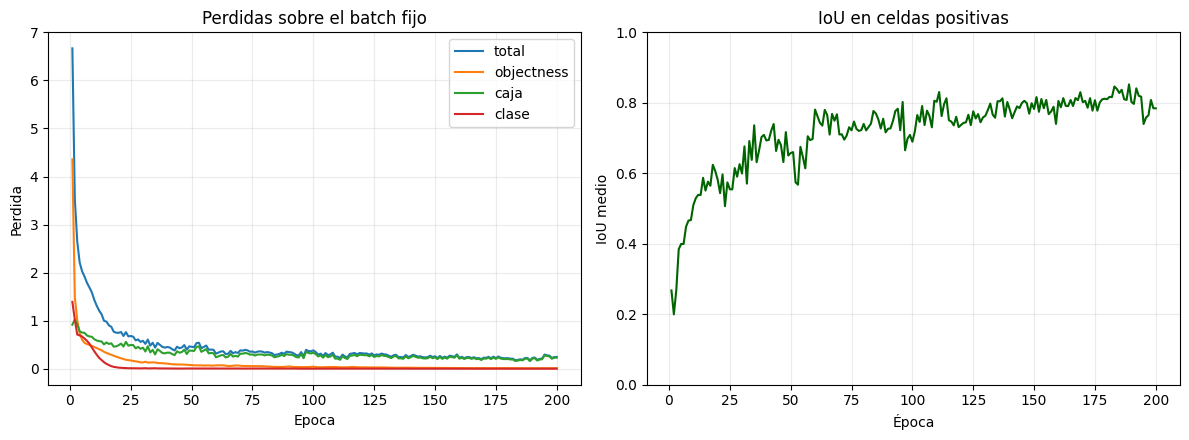

In [21]:
if TRAINING_DONE:
    history_df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for key, label in [("total", "total"), ("obj", "objectness"), ("box", "caja"), ("cls", "clase")]:
        axes[0].plot(history_df["epoch"], history_df[key], label=label)
    axes[0].set(title="Perdidas sobre el batch fijo", xlabel="Epoca", ylabel="Perdida")
    axes[0].grid(alpha=0.25)
    axes[0].legend()
    axes[1].plot(history_df["epoch"], history_df["mean_iou"], color="darkgreen")
    axes[1].set(title="IoU en celdas positivas", xlabel="Época", ylabel="IoU medio", ylim=(0, 1))
    axes[1].grid(alpha=0.25)
    fig.tight_layout()
    plt.show()          # la figura solo se muestra aquí; no se guarda en disco
    plt.close(fig)
else:
    print("Curvas omitidas porque no hubo entrenamiento.")

## 9. Overlay de cajas GT y predicciones

Dibuja las cajas reales y las predicciones de mayor score sobre cada corte, primero con el modelo **sin entrenar** y luego tras el overfit (solo se muestran, no se guardan). **Resultado esperado:** verde = GT; magenta discontinuo = predicción, con clase y score. Se muestran candidatas antes de NMS; esta celda no agrega un postprocesador nuevo.

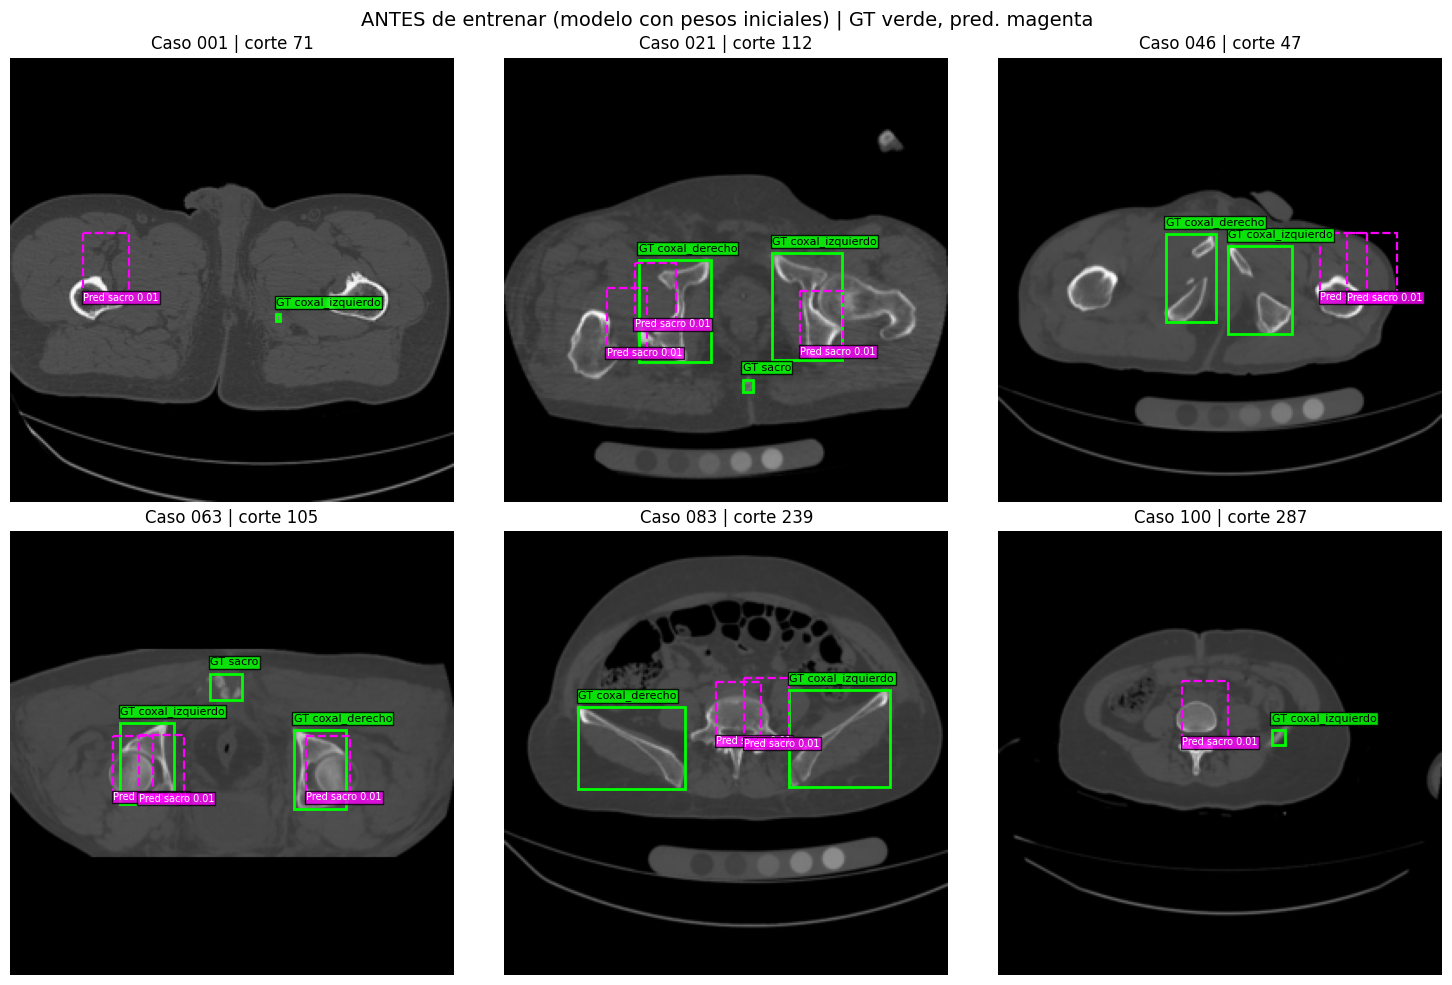

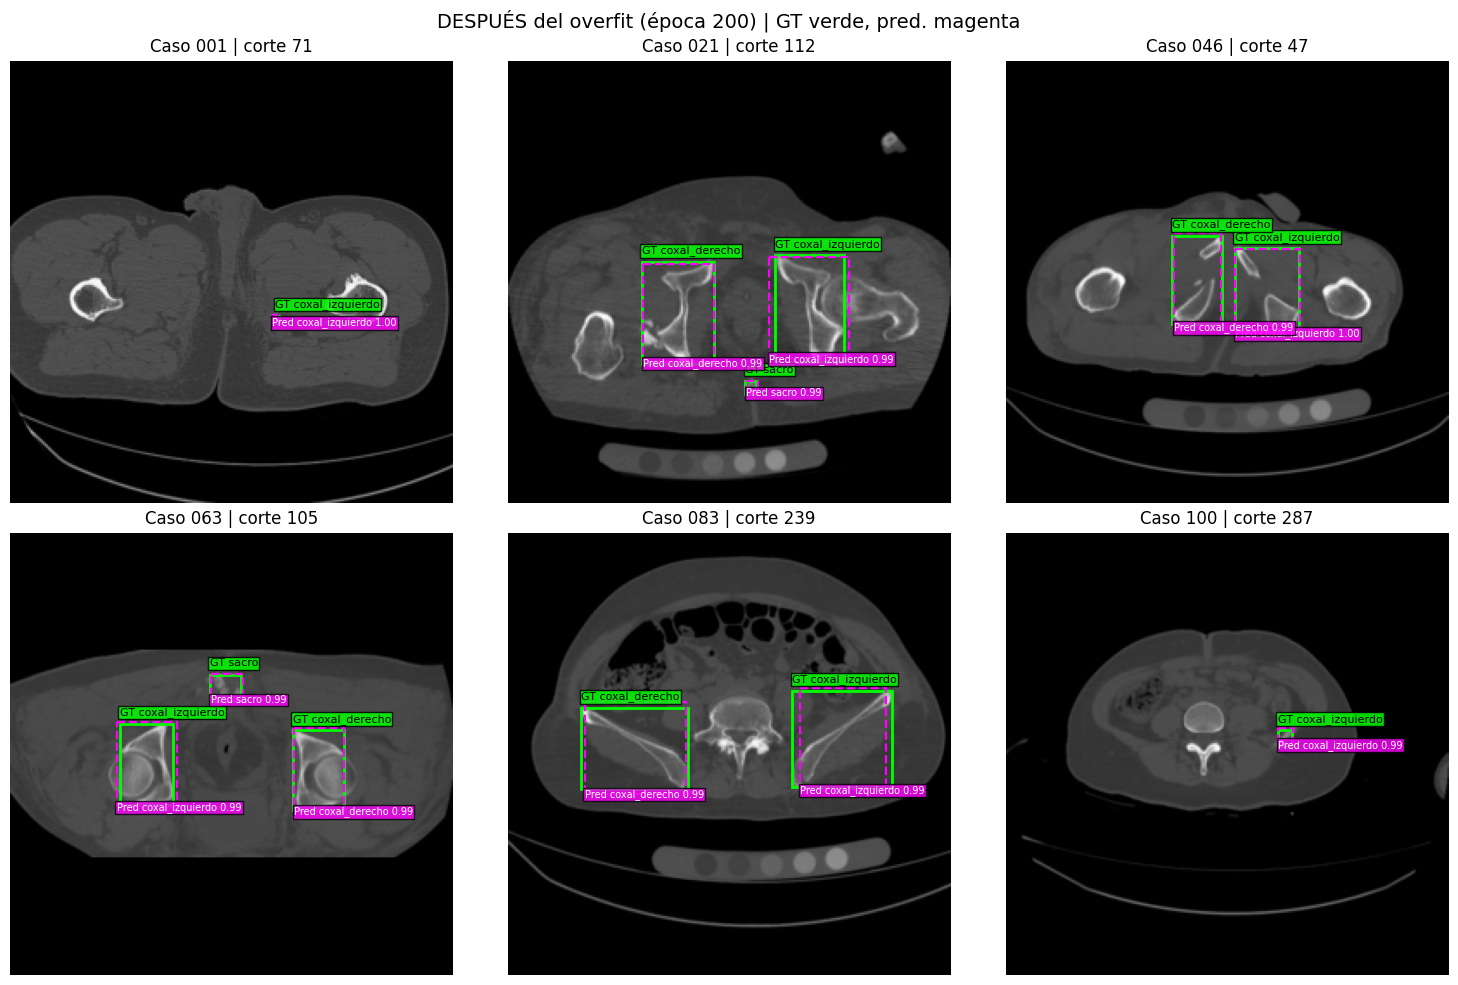

Se muestran las candidatas de mayor score (tantas como cajas GT) antes de NMS; la medición objetiva está en la sección 9b.


In [22]:
def plot_gt_vs_pred(decoded, titulo):
    """GT (verde) vs. predicciones de mayor score (magenta, antes de NMS). Solo se muestra, no se guarda."""
    n = len(batch_targets)
    rows_n = int(np.ceil(n / 3))
    fig, axes = plt.subplots(rows_n, 3, figsize=(15, 5 * rows_n), squeeze=False)
    for index, ax in enumerate(axes.ravel()):
        if index >= n:
            ax.axis("off")
            continue
        image = batch_images[index, 0].cpu().numpy()
        target = batch_targets[index]
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        for box, class_id in zip(target["boxes"], target["labels"]):
            x1, y1, x2, y2 = [float(v) for v in box]
            name = CLASS_NAMES[int(class_id)]
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="lime", linewidth=2))
            ax.text(x1, max(3, y1-5), f"GT {name}", color="black", fontsize=8,
                    bbox={"facecolor":"lime", "alpha":0.85, "pad":1})

        prediction = decoded[index]
        top_indices = prediction["scores"].argsort(descending=True)[:max(1, len(target["boxes"]))]
        for pred_index in top_indices.tolist():
            box = prediction["boxes"][pred_index].cpu().tolist()
            score = float(prediction["scores"][pred_index].cpu())
            class_id = int(prediction["labels"][pred_index].cpu())
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                           edgecolor="magenta", linewidth=1.6, linestyle="--"))
            ax.text(x1, min(IMAGE_SIZE-5, y2+2), f"Pred {CLASS_NAMES[class_id]} {score:.2f}",
                    color="white", fontsize=7,
                    bbox={"facecolor":"magenta", "alpha":0.8, "pad":1})
        ax.set_title(f"Caso {target['case_id']} | corte {target['slice_index']}")
        ax.axis("off")
    fig.suptitle(titulo, fontsize=14)
    fig.tight_layout()
    plt.show()          # solo se muestra; no se guarda en disco
    plt.close(fig)


if TRAINING_DONE:
    plot_gt_vs_pred(initial_decoded, "ANTES de entrenar (modelo con pesos iniciales) | GT verde, pred. magenta")

    model.eval()
    with torch.no_grad():
        final_logits = model(batch_images)
        decoded = decode_predictions(final_logits, score_thresh=0.0, img_size=IMAGE_SIZE)
    plot_gt_vs_pred(decoded, "DESPUÉS del overfit (época %d) | GT verde, pred. magenta" % EPOCHS)
    print("Se muestran las candidatas de mayor score (tantas como cajas GT) antes de NMS; "
          "la medición objetiva está en la sección 9b.")
else:
    print("Overlay omitido porque no hubo entrenamiento.")


## 9b. Diagnóstico de overfitting

Compara el estado **inicial** (época 0) con el **final** sobre el batch de entrenamiento y sobre validación, todo en modo `eval`. **Cómo leerlo:** en esta prueba el sobreajuste es el objetivo. Si el batch fijo mejora mucho y la validación queda muy por debajo, el modelo **memorizó** y no generaliza; eso es lo esperado en semana 9 y **no** debe reportarse como resultado final. También verifica que `obj`, `box` y `cls` reciben gradiente y que lo medido en `train` coincide con `eval`.

                    métrica  train ini  train fin  val ini  val fin
              Pérdida total      6.393      0.257    6.330    6.316
IoU medio (top-score/clase)      0.000      0.780    0.011    0.091
                 Recall@0.5      0.000      0.917    0.000    0.069
                Recall@0.75      0.000      0.750    0.000    0.000
          mAP@0.5 (sin NMS)      0.000      0.847    0.000    0.027


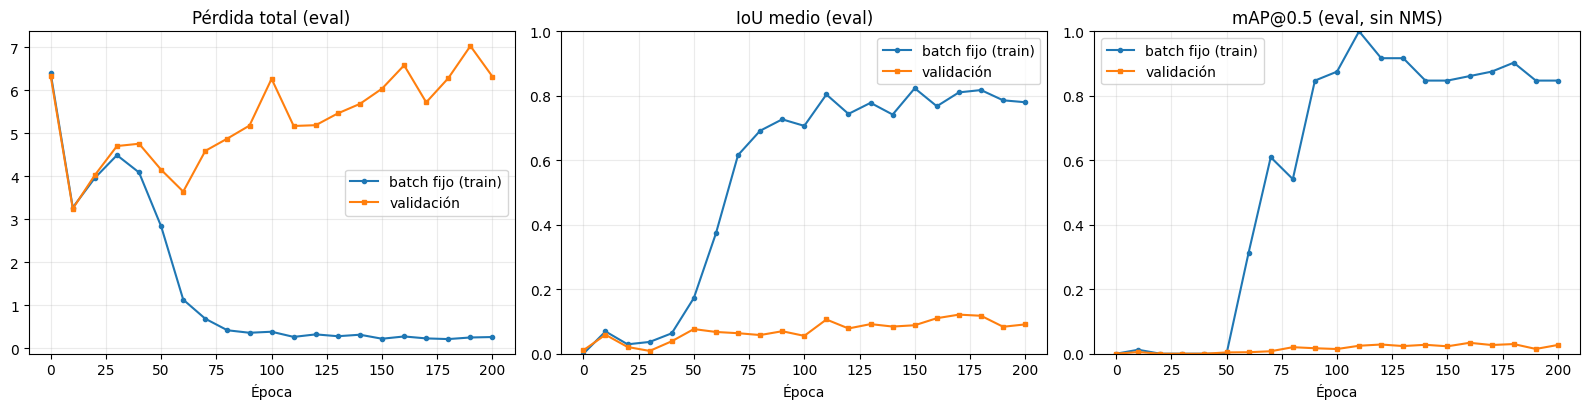


Norma del gradiente por término de la pérdida:
término  backbone.conv1.weight  head.pred.weight
    obj              1.484e-01         5.320e-02
    box              4.150e-01         6.548e+00
    cls              3.988e-02         2.064e-02

=== Lectura ===
Memorización del batch: IoU=0.780 (meta interna >= 0.80), recall@0.5=0.92 -> PARCIAL: todavía no memoriza del todo
Pérdida (eval) bajó 6.135 (96%) desde la época 0.
Consistencia train/eval: IoU en el bucle (train)=0.784 vs eval=0.780 (dif=0.004) -> coherente
Brecha train-validación: IoU 0.780 vs 0.091 (gap=0.689) -> sobreajuste esperado: memoriza el batch y NO generaliza (normal en esta prueba)


In [23]:
if TRAINING_DONE and eval_history:
    ev = pd.DataFrame(eval_history)
    first, last = ev.iloc[0], ev.iloc[-1]
    has_val = "val_mean_iou" in ev.columns

    # --- 1) Tabla inicial vs final (train fijo y validación) ---
    metricas = [("Pérdida total", "loss_total"), ("IoU medio (top-score/clase)", "mean_iou"),
                ("Recall@0.5", "recall50"), ("Recall@0.75", "recall75"), ("mAP@0.5 (sin NMS)", "map50")]
    filas = []
    for nombre, key in metricas:
        fila = {"métrica": nombre,
                "train ini": first[f"train_{key}"], "train fin": last[f"train_{key}"]}
        if has_val:
            fila.update({"val ini": first[f"val_{key}"], "val fin": last[f"val_{key}"]})
        filas.append(fila)
    print(pd.DataFrame(filas).round(3).to_string(index=False))

    # --- 2) Curvas train vs validación (solo se muestran) ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    for ax, key, titulo in zip(axes, ["loss_total", "mean_iou", "map50"],
                               ["Pérdida total (eval)", "IoU medio (eval)", "mAP@0.5 (eval, sin NMS)"]):
        ax.plot(ev["epoch"], ev[f"train_{key}"], marker="o", ms=3, label="batch fijo (train)")
        if has_val:
            ax.plot(ev["epoch"], ev[f"val_{key}"], marker="s", ms=3, label="validación")
        ax.set(title=titulo, xlabel="Época")
        ax.grid(alpha=0.25)
        ax.legend()
    axes[1].set_ylim(0, 1); axes[2].set_ylim(0, 1)
    fig.tight_layout()
    plt.show()          # solo se muestra; no se guarda en disco
    plt.close(fig)

    # --- 3) ¿Reciben gradiente obj, box y cls? (norma por término en dos capas clave) ---
    params = dict(model.named_parameters())
    capas = [n for n in ("backbone.conv1.weight", "head.pred.weight") if n in params]
    grad_rows = []
    model.eval()
    for termino in ("obj", "box", "cls"):
        model.zero_grad(set_to_none=True)
        salida = model(batch_images).float()
        perdida = grid_detection_loss(salida, grid_targets, lambdas=LAMBDAS)[termino]
        perdida.backward()
        grad_rows.append({"término": termino, **{
            n: (float(params[n].grad.norm()) if params[n].grad is not None else 0.0) for n in capas}})
    model.zero_grad(set_to_none=True)
    print("\nNorma del gradiente por término de la pérdida:")
    print(pd.DataFrame(grad_rows).to_string(index=False, float_format=lambda v: f"{v:.3e}"))

    # --- 4) Veredicto automático ---
    print("\n=== Lectura ===")
    ti, tr = last["train_mean_iou"], last["train_recall50"]
    print(f"Memorización del batch: IoU={ti:.3f} (meta interna >= 0.80), recall@0.5={tr:.2f} -> "
          + ("OK, memoriza" if ti >= 0.80 and tr >= 0.9 else "PARCIAL: todavía no memoriza del todo"))
    mejora = first["train_loss_total"] - last["train_loss_total"]
    print(f"Pérdida (eval) bajó {mejora:.3f} ({100*mejora/max(first['train_loss_total'],1e-9):.0f}%) desde la época 0.")
    en_loop = history[-1]["mean_iou"]
    dif = abs(en_loop - ti)
    print(f"Consistencia train/eval: IoU en el bucle (train)={en_loop:.3f} vs eval={ti:.3f} (dif={dif:.3f}) -> "
          + ("coherente" if dif < 0.15 else "REVISAR: diferencia grande, posible efecto de BatchNorm train vs eval"))
    if has_val:
        gap = ti - last["val_mean_iou"]
        print(f"Brecha train-validación: IoU {ti:.3f} vs {last['val_mean_iou']:.3f} (gap={gap:.3f}) -> "
              + ("sobreajuste esperado: memoriza el batch y NO generaliza (normal en esta prueba)"
                 if gap > 0.2 else "brecha pequeña: no hay evidencia de sobreajuste fuerte"))
    else:
        print("Sin validación disponible: no se puede medir la brecha de generalización.")
else:
    print("Diagnóstico omitido porque no hubo entrenamiento.")


## 10. Lectura del resultado y reproducibilidad

- En una prueba de overfit, la **pérdida total debería bajar** y el **IoU del batch fijo debería subir**. Eso comprueba que el detector aprende esas muestras; no mide generalización a pacientes nuevos.
- Las pérdidas `obj`, `box` y `cls` deben ser finitas y contribuir. `grad(conv1)` distinto de cero indica que el gradiente llega hasta el backbone.
- En el overlay, **verde** son cajas GT y **magenta discontinuo** las predicciones de mayor score, antes de NMS. Revísalo junto con la curva; una imagen aislada no basta.
- Los artefactos quedan bajo `evidencias/entrenamiento_semana9/`: checkpoint (`.pth`), `historial_overfit.csv` y `metricas_eval_overfit.csv`. Curvas y overlays no se guardan: se ven en las celdas.
- Si falta CUDA o PyTorch es CPU-only, la primera celda falla explícitamente; no se presenta un entrenamiento en CPU como cumplimiento del requisito de GPU.
- Si faltan los datos, la celda 3 enumera las rutas `.mha` ausentes y el entrenamiento no se considera completado.